**Q1**

What is the difference between regression and classification?
- regression fits a line through continuous data points, while classification a decision boundary to separate data into specific classes.

What is a confusion table? What does it help us understand about a model's performance?
- It shows what the model predicted vs. what the true values actually were. it determines if the outcome is a true positive or negative/ false positive or negative.

What does the SSE quantify about a particular model?
- How much total prediction error the model makes. SSE measures the variation in the data that your model fails to explain.

What are overfitting and underfitting?
- underfitting is when a model is too basic/small to fit a set of data. Overfitting happens when a model is too complex and captures excess information instead of just what is being looked for.

Why does splitting the data into training and testing sets, and choosing by evaluating accuracy or SSE on the test set, improve model performance?
 - it improves model performance because it forces the model to be evaluated on new/unseen data. it helps us measure how well the model generalizes information.

With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.
- Predicting a class label is simple, but it discards information about uncertainty. predicting probabilities preserves uncertainty and allows more flexible, cost-sensitive decisions, but it is more complex to interpret

In [3]:
from google.colab import files
uploaded = files.upload()


Saving USA_cars_datasets.csv to USA_cars_datasets.csv


Dimensions: (2499, 3)
   price  year  mileage
0   6300  2008   274117
1   2899  2011   190552
2   5350  2018    39590
3  25000  2014    64146
4  27700  2018     6654
Optimal k: 49 with MSE: 109931222.53539108


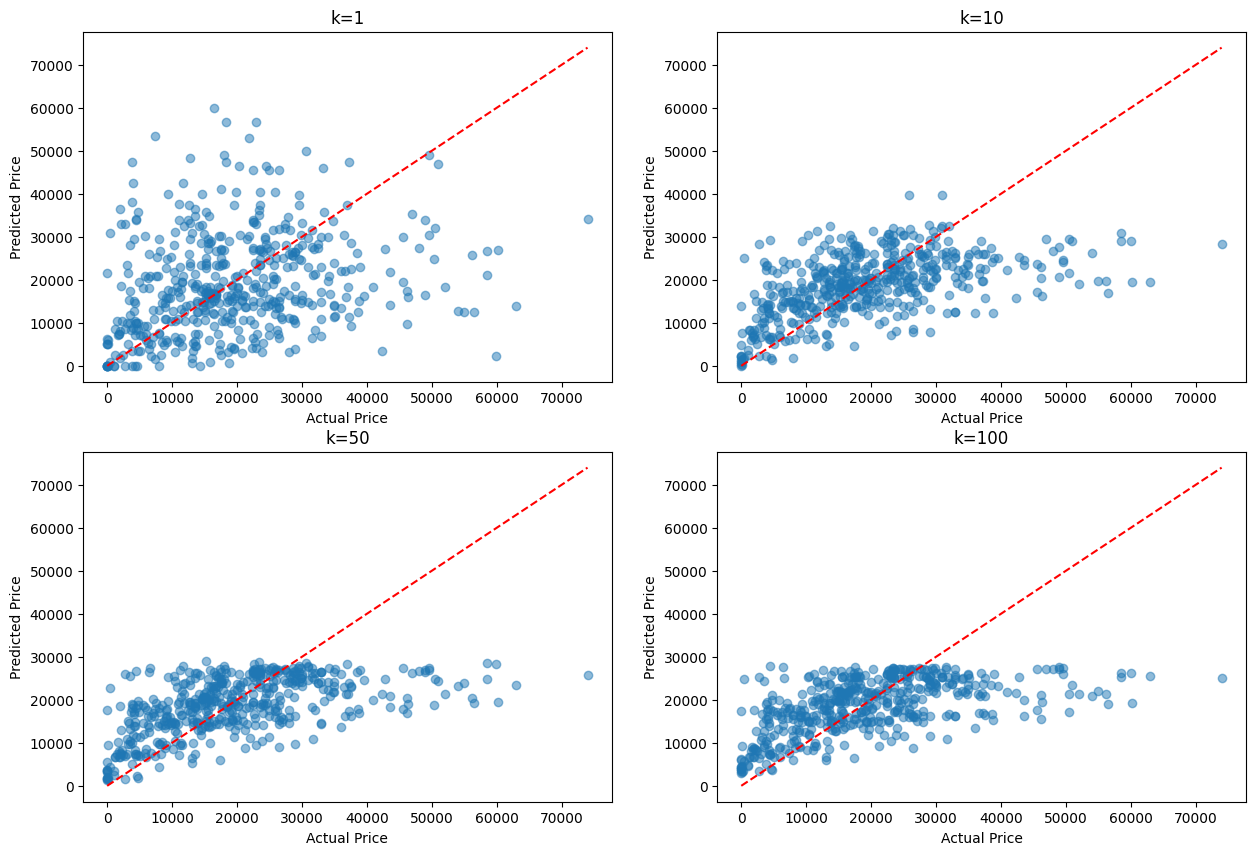

In [4]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

# 1. Load data
df = pd.read_csv('USA_cars_datasets.csv')
df_subset = df[['price', 'year', 'mileage']].dropna()
print("Dimensions:", df_subset.shape)
print(df_subset.head())

# 2. Maxmin normalize
scaler = MinMaxScaler()
df_subset[['year', 'mileage']] = scaler.fit_transform(df_subset[['year', 'mileage']])

# 3. Split sample
X = df_subset[['year', 'mileage']]
y = df_subset['price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4 & 5. Loop for k and find optimal
k_range = range(1, 101)
mse_results = []
best_k = -1
min_mse = float('inf')

for k in k_range:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    mse_results.append(mse)
    if mse < min_mse:
        min_mse = mse
        best_k = k

print(f"Optimal k: {best_k} with MSE: {min_mse}")

# Plotting for representative k
k_plot = [1, 10, 50, 100]
plt.figure(figsize=(15, 10))
for i, k in enumerate(k_plot):
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)

    plt.subplot(2, 2, i+1)
    plt.scatter(y_test, y_pred, alpha=0.5)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    plt.title(f'k={k}')
    plt.xlabel('Actual Price')
    plt.ylabel('Predicted Price')
plt.show()

6. The plots and error rates illustrate the bias-variance tradeoff, the model is overfitting. It memorizes the training data too closely, including the noise. the model is underfitting. By averaging over a large number of neighbors, the model smooths out the distinct features of the specific car too much. It loses the ability to distinguish differences, the model balances bias and variance, capturing the underlying trend of how year and mileage affect price.

Q3
I could not find the data set for the animals.csv I ony saw zoo.csv and I did not think that was correct to use. Where is the data for this?

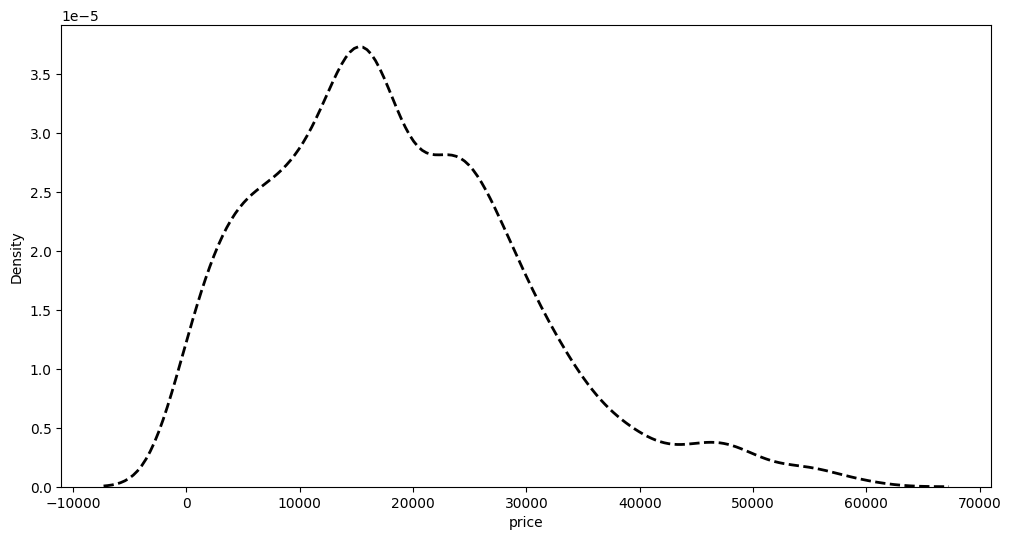

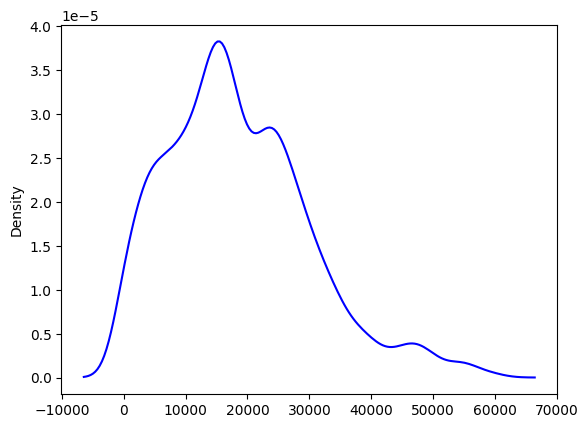

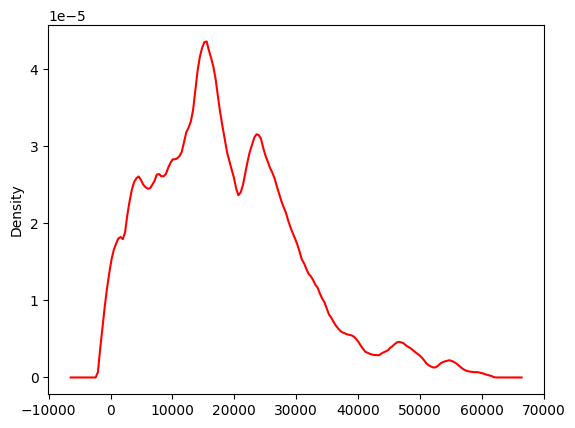

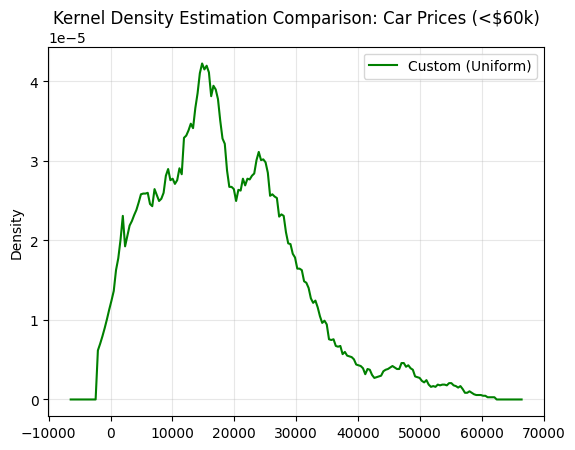

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def my_kde_plot(data, kernel='gaussian', bw='silverman', ax=None, label=None, color=None):
    """
    Generate a Kernel Density Estimate plot from scratch.

    Parameters:
    - data: Pandas Series or Numpy array (1D)
    - kernel: 'gaussian', 'uniform', 'epanechnikov' (default: 'gaussian')
    - bw: Bandwidth method ('silverman') or float value (default: 'silverman')
    - ax: Matplotlib axes object (optional)
    - label: Label for the plot legend (optional)
    - color: Color for the plot line (optional)
    """

    # --- 1. Data Handling ---
    # Convert input to numpy array and remove NaNs
    if isinstance(data, pd.Series):
        x = data.dropna().values
    else:
        x = np.array(data)
        x = x[~np.isnan(x)]

    n = len(x)
    if n == 0:
        raise ValueError("Input data is empty or all NaN.")

    # --- 2. Bandwidth Selection (Silverman's Rule of Thumb) ---
    # h = 0.9 * min(std, IQR/1.34) * n^(-1/5)
    if bw == 'silverman':
        std_dev = np.std(x, ddof=1)
        q75, q25 = np.percentile(x, [75 ,25])
        iqr = q75 - q25

        # Use the smaller of std or IQR/1.34 to be robust to outliers
        sigma = min(std_dev, iqr / 1.34) if iqr > 0 else std_dev
        if sigma == 0:
            sigma = 1.0 # Fallback for constant data

        h = 0.9 * sigma * (n ** (-0.2))
    else:
        h = float(bw)

    # --- 3. Define the Grid ---
    # Create evaluation points (grid) covering the range of data + padding
    # Padding ensures the tails of the density don't get cut off
    grid_min = x.min() - 3 * h
    grid_max = x.max() + 3 * h
    grid_size = 200
    grid = np.linspace(grid_min, grid_max, grid_size)

    # --- 4. Vectorized Kernel Calculation ---
    # We need to compute u = (grid_point - data_point) / h for every pair.
    # Using broadcasting:
    # grid[:, np.newaxis] is shape (200, 1)
    # x is shape (n,)
    # Result `u` is shape (200, n)
    u = (grid[:, np.newaxis] - x) / h

    # --- 5. Apply Kernel Function ---
    if kernel == 'gaussian':
        # K(u) = (1 / sqrt(2*pi)) * exp(-0.5 * u^2)
        k_u = (1 / np.sqrt(2 * np.pi)) * np.exp(-0.5 * u**2)

    elif kernel == 'uniform': # Boxcar
        # K(u) = 0.5 if |u| <= 1 else 0
        # Note: 0.5 ensures area integrates to 1 over [-1, 1]
        k_u = np.where(np.abs(u) <= 1, 0.5, 0)

    elif kernel == 'epanechnikov':
        # K(u) = 0.75 * (1 - u^2) if |u| <= 1 else 0
        k_u = np.where(np.abs(u) <= 1, 0.75 * (1 - u**2), 0)

    else:
        raise ValueError(f"Unknown kernel: {kernel}")

    # --- 6. Sum and Normalize ---
    # Density at each grid point = (1 / (n * h)) * sum(K(u))
    # Sum across the rows (axis=1) to get density for each grid point
    density = np.sum(k_u, axis=1) / (n * h)

    # --- 7. Plotting ---
    if ax is None:
        fig, ax = plt.subplots()

    if label is None:
        label = f'{kernel} (h={h:.2f})'

    ax.plot(grid, density, label=label, color=color)
    ax.set_ylabel('Density')

    return ax

# --- Comparison on Class Data (Car Prices) ---

# Load data and filter outliers for clearer visualization
try:
    df = pd.read_csv('USA_cars_datasets.csv')
    data = df[df['price'] < 60000]['price'] # Filter high outliers
    title = "Car Prices (<$60k)"
except:
    # Fallback to random data if file is missing
    np.random.seed(42)
    data = np.concatenate([np.random.normal(0, 1, 500), np.random.normal(4, 1.5, 300)])
    title = "Synthetic Bimodal Data"

plt.figure(figsize=(12, 6))

# 1. Reference: Seaborn KDE (Gaussian)
sns.kdeplot(data, color='black', linestyle='--', linewidth=2, label='Seaborn (Gaussian)')

# 2. Custom: Gaussian
my_kde_plot(data, kernel='gaussian', color='blue', label='Custom (Gaussian)')

# 3. Custom: Epanechnikov
my_kde_plot(data, kernel='epanechnikov', color='red', label='Custom (Epanechnikov)')

# 4. Custom: Uniform
my_kde_plot(data, kernel='uniform', color='green', label='Custom (Uniform)')

plt.title(f"Kernel Density Estimation Comparison: {title}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('custom_kde_comparison.png')
plt.show()